# Fig: Dev Experiment Compare Interaction Terms

Compare interaction terms with binary prev violation history vs. filtered prev violation history


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

from violmulti.experiments.experiment import load_experiment
from violmulti.experiments.experiment_compare_models import ExperimentCompareModels
from violmulti.models.multiclass_logistic_regression import MultiClassLogisticRegression
from violmulti.models.binary_logistic_regression import BinaryLogisticRegression
from violmulti.visualizations.model_visualizer import ModelVisualizer
from violmulti.features.design_matrix_generator_PWM import *

from violmulti.visualizations.model_visualizer import *

from violmulti.data import ANIMAL_IDS
from violmulti.experiments import STANDARD_SIGMAS
import config as c

sns.set_context("talk")
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
shared_cols = {
    "session": lambda df: (copy(df.session)),
    "bias": lambda df: (add_bias_column(df)),
    "s_a": lambda df: (standardize(df.s_a)),
    "s_b": lambda df: (standardize(df.s_b)),
    "prev_avg_stim": lambda df: prev_avg_stim(df, mask_prev_violation=True),
    "prev_correct": lambda df: (prev_correct_side(df)),
    "prev_choice": lambda df: (prev_choice(df)),
}

models_config = {
    "base" : {
        "model_class": BinaryLogisticRegression,
        "dmg_config": {
            **shared_cols,
            "labels" : binary_choice_labels(),
        },
    },
    "prev_viol_binary" : {
        "model_class": MultiClassLogisticRegression,
        "dmg_config": {
            **shared_cols,
            "prev_violation": lambda df: prev_violation(df),
            "labels": multi_choice_labels(),
        },
        "lr_only_eval": True,
    },
    "prev_viol_filtered" : {
        "model_class": MultiClassLogisticRegression,
        "dmg_config": {
            **shared_cols,
            "filt_prev_violation": lambda df: (
                filtered_prev_viol(df, get_animals_tau(df, "prev_violation"))
            ),
            "labels": multi_choice_labels(),
        },
        "lr_only_eval": True,
    },
    "prev_viol_binary_itrx" : {
        "model_class": MultiClassLogisticRegression,
        "dmg_config": {
            **shared_cols,
            "prev_violation": lambda df: prev_violation(df),
            "sa_x_prev_viol": lambda df: stim_filt_binary_intrx(df, "s_a"),
            "sb_x_prev_viol": lambda df: stim_filt_binary_intrx(df, "s_b"),
            "labels": multi_choice_labels(),
        },
        "lr_only_eval": True,
    },
    "prev_viol_filtered_itrx" : {
        "model_class": MultiClassLogisticRegression,
        "dmg_config": {
            **shared_cols,
            "filt_prev_violation": lambda df: (
                filtered_prev_viol(df, get_animals_tau(df, "prev_violation"))
            ),
            "sa_x_prev_viol": lambda df: (
                stim_filt_viol_intrx(df, "s_a", get_animals_tau(df, "prev_violation"))
            ),
            "sb_x_prev_viol": lambda df: (
            stim_filt_viol_intrx(df, "s_b", get_animals_tau(df, "prev_violation"))
             ),
            "labels": multi_choice_labels(),
        },
        "lr_only_eval":True,
    },
}
params = {
    "animals": ANIMAL_IDS,
    "data_type": "new_trained",
    "sigmas": STANDARD_SIGMAS,
    "random_state": 47,
    "eval_train": True,
    "null_mode": "binary",
    "model_config": models_config,
}

save_name = "2025_04_16_fig5_compare_to_binary_rs47.pkl"

ORDER = [
    "base",
    "prev_viol_binary",
    "prev_viol_binary_itrx",
    "prev_viol_filtered",
    "prev_viol_filtered_itrx",
]

## Run


In [22]:
experiment = ExperimentCompareModels(params)
experiment.run()
experiment.save(save_name)

Loading dataset type : new_trained
DataLoader: Loading data for animal ids:  ['W051', 'W060', 'W065', 'W066', 'W068', 'W072', 'W073', 'W074', 'W075', 'W078', 'W080', 'W081', 'W083', 'W088', 'W089', 'W094']

 >>>> evaluating animal W051 <<<<

 ***** evaluating model base w/ sigma 0.07 *****


/Users/jessbreda/anaconda3/envs/viol-multi/lib/python3.10/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 32027.226474
         Iterations: 12
         Function evaluations: 61
         Gradient evaluations: 49

 ***** evaluating model base w/ sigma 0.13 *****


/Users/jessbreda/anaconda3/envs/viol-multi/lib/python3.10/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 32417.244752
         Iterations: 13
         Function evaluations: 62
         Gradient evaluations: 50

 ***** evaluating model base w/ sigma 0.25 *****


...

         Current function value: 45250.291768
         Iterations: 28
         Function evaluations: 69
         Gradient evaluations: 57

 ***** evaluating model prev_viol_binary_itrx w/ sigma 8 *****
Optimization terminated successfully.
         Current function value: 45250.180659
         Iterations: 29
         Function evaluations: 44
         Gradient evaluations: 44

 ***** evaluating model prev_viol_binary_itrx w/ sigma 16 *****
Optimization terminated successfully.
         Current function value: 45250.152880
         Iterations: 29
         Function evaluations: 44
         Gradient evaluations: 44

 ***** evaluating model prev_viol_filtered_itrx w/ sigma 0.07 *****
Optimization terminated successfully.
         Current function value: 45582.510573
         Iterations: 31
         Function evaluations: 46
         Gradient evaluations: 46

 ***** evaluating model prev_viol_filtered_itrx w/ sigma 0.13 *****


/Users/jessbreda/anaconda3/envs/viol-multi/lib/python3.10/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 45057.061574
         Iterations: 30
         Function evaluations: 39
         Gradient evaluations: 39

 ***** evaluating model prev_viol_filtered_itrx w/ sigma 0.25 *****
Optimization terminated successfully.
         Current function value: 44842.080042
         Iterations: 29
         Function evaluations: 39
         Gradient evaluations: 39

 ***** evaluating model prev_viol_filtered_itrx w/ sigma 0.5 *****
Optimization terminated successfully.
         Current function value: 44772.599998
         Iterations: 28
         Function evaluations: 37
         Gradient evaluations: 37

 ***** evaluating model prev_viol_filtered_itrx w/ sigma 1 *****


/Users/jessbreda/anaconda3/envs/viol-multi/lib/python3.10/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 44754.278271
         Iterations: 27
         Function evaluations: 85
         Gradient evaluations: 74

 ***** evaluating model prev_viol_filtered_itrx w/ sigma 2 *****
Optimization terminated successfully.
         Current function value: 44749.629941
         Iterations: 28
         Function evaluations: 37
         Gradient evaluations: 37

 ***** evaluating model prev_viol_filtered_itrx w/ sigma 4 *****
Optimization terminated successfully.
         Current function value: 44748.463457
         Iterations: 28
         Function evaluations: 37
         Gradient evaluations: 37

 ***** evaluating model prev_viol_filtered_itrx w/ sigma 8 *****
Optimization terminated successfully.
         Current function value: 44748.171558
         Iterations: 28
         Function evaluations: 37
         Gradient evaluations: 37

 ***** evaluating model prev_viol_filtered_itrx w/ sigma 16 *****
Optimization terminated successfully.
         Current function value

## Visualize


In [25]:
experiment = load_experiment(save_name)
mvc = ModelVisualizerCompare(experiment)

/var/folders/__/8jn6qz211155h1xb451s5zcr0000gn/T/ipykernel_80064/2431235986.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for model_name, model_df in df.groupby("model_name"):


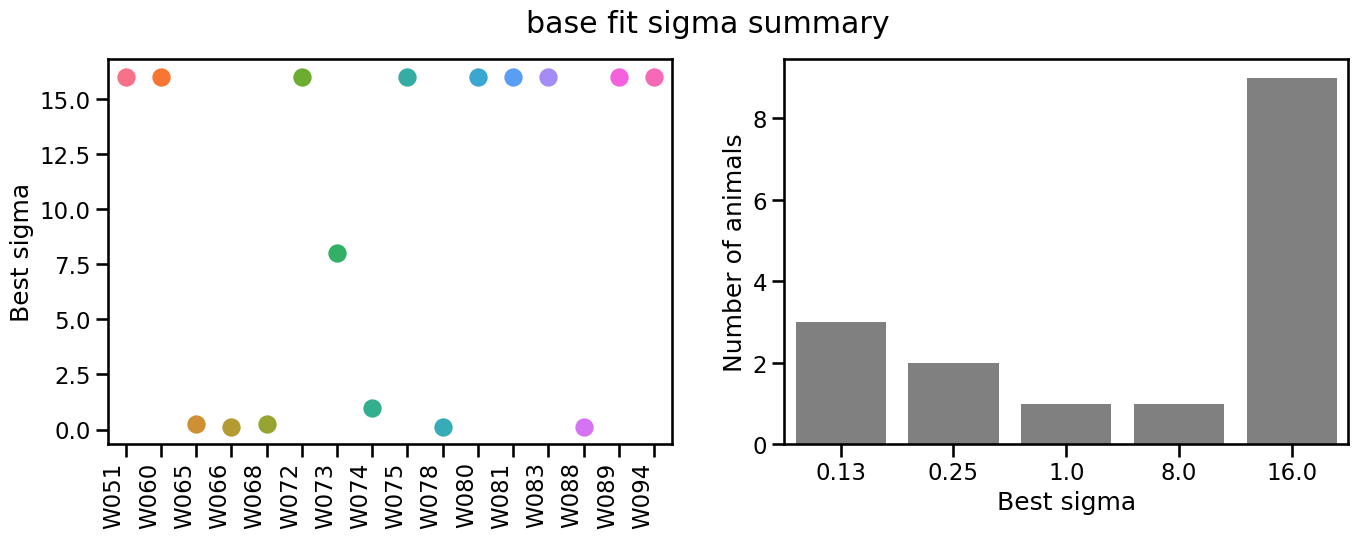

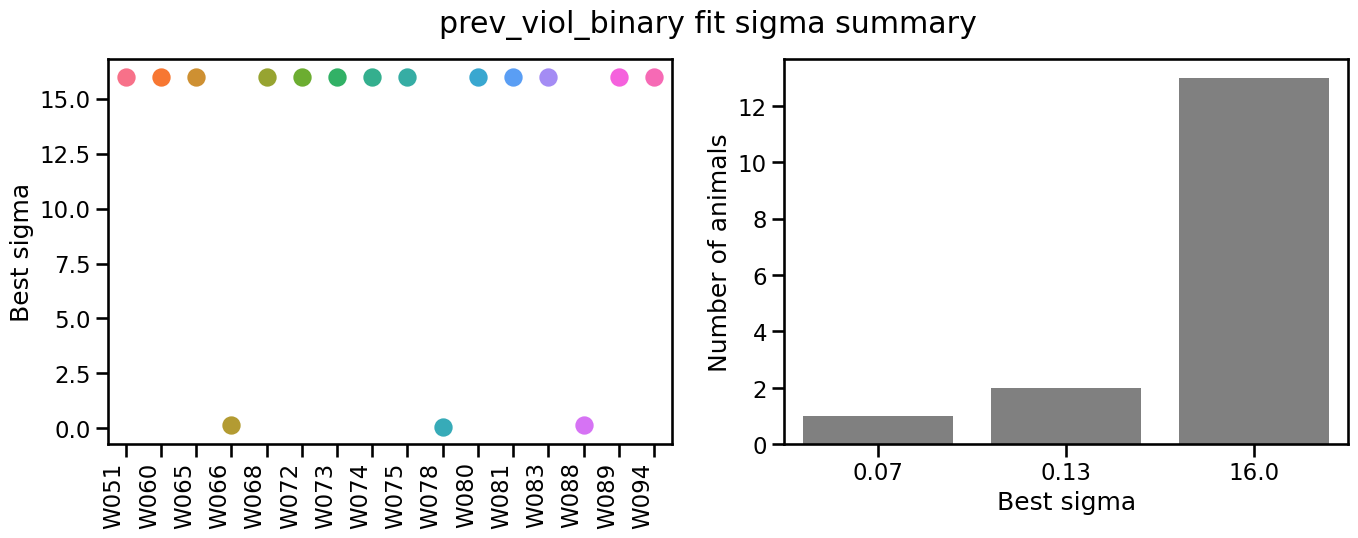

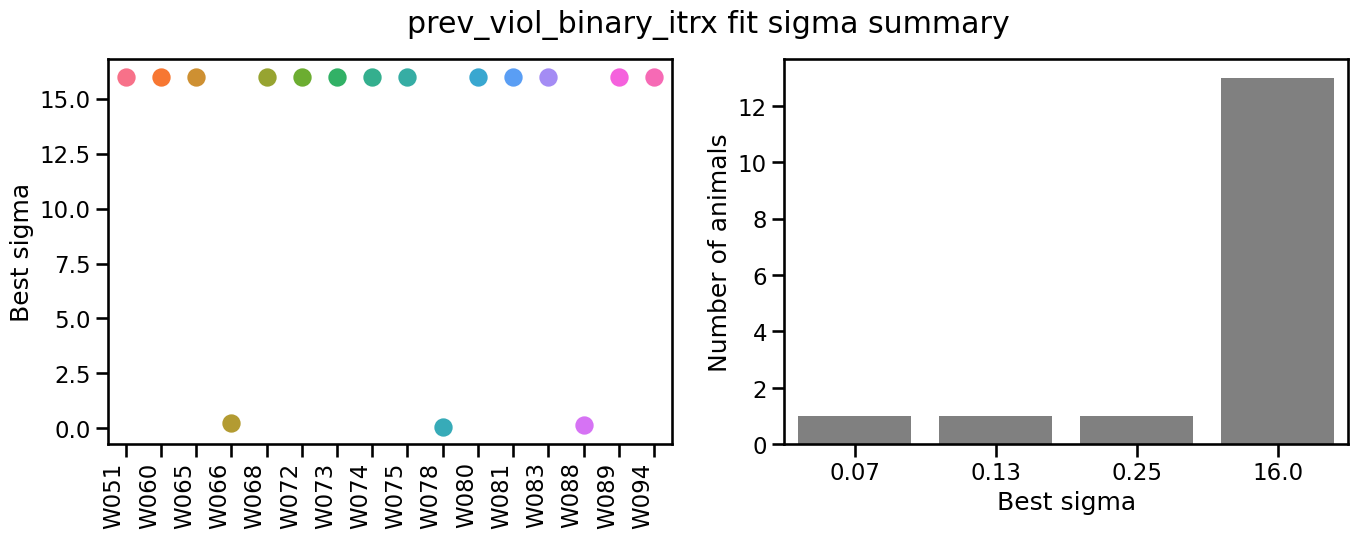

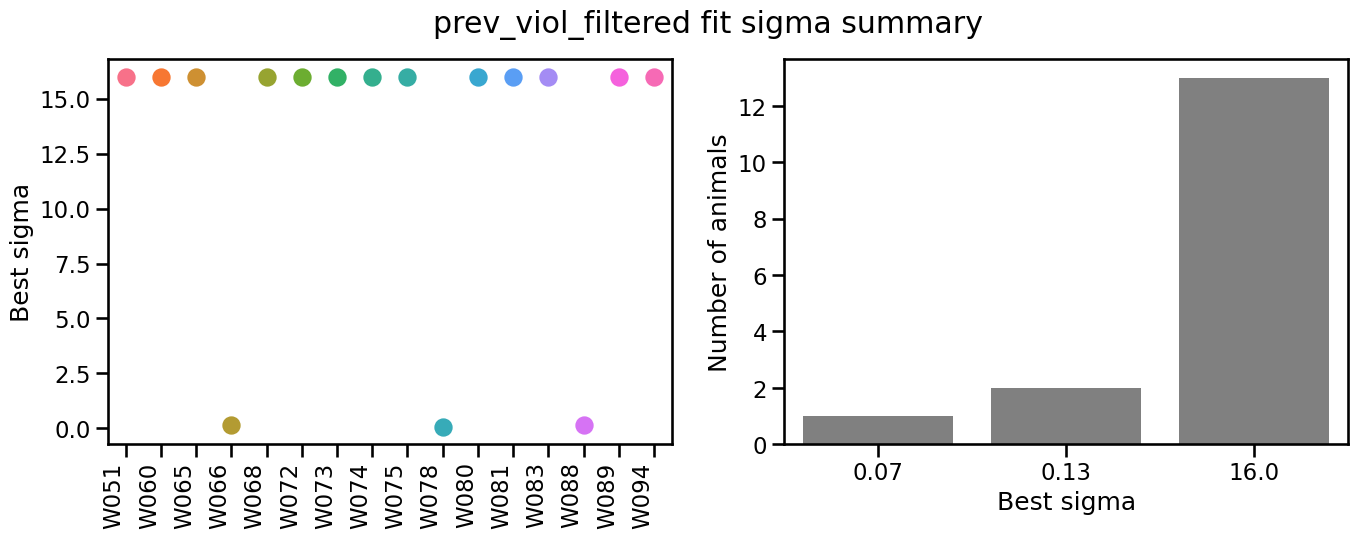

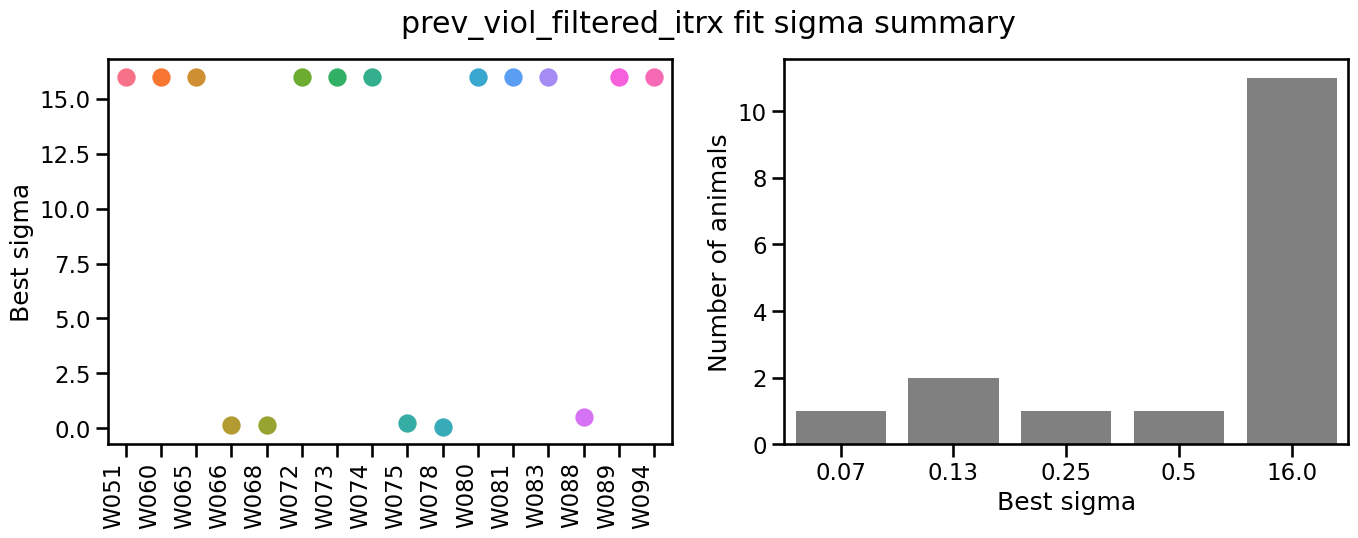

In [26]:
df = mvc.find_best_fit(group="model_name")
df["model_name"] = pd.Categorical(df["model_name"], categories=ORDER, ordered=True)
for model_name, model_df in df.groupby("model_name"):
    mvc.plot_sigma_summary(model_df, title=f"{model_name} fit sigma summary")

/var/folders/__/8jn6qz211155h1xb451s5zcr0000gn/T/ipykernel_80064/3658154948.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ii, (model_name, model_df) in enumerate(best_fit_by_model.groupby("model_name")):
/Users/jessbreda/Desktop/github/violations-multinomial/src/violmulti/visualizations/model_visualizer.py:345: UserWarning: The palette list has more values (3) than needed (1), which may not be intended.
  sns.barplot(


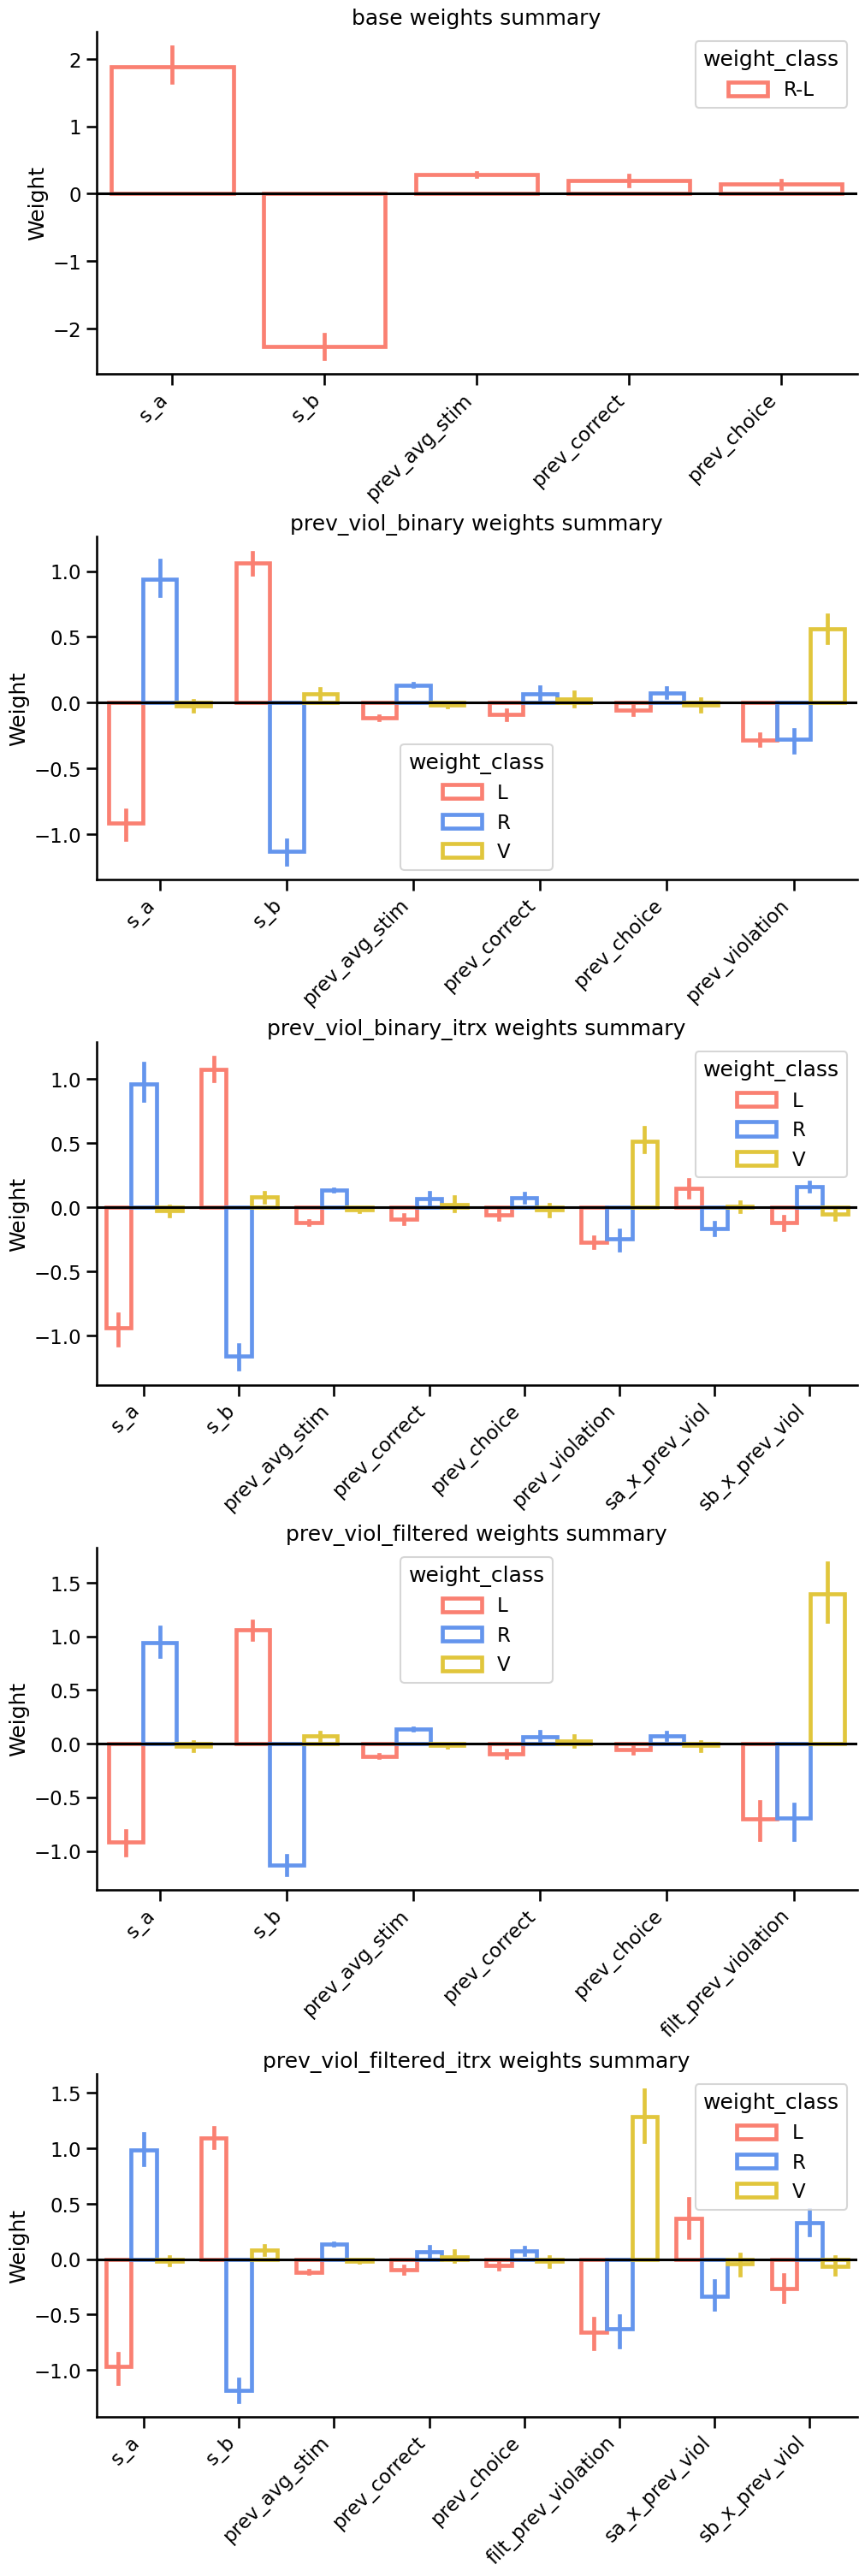

In [27]:
fig, ax = plt.subplots(
    len(ORDER), 1, figsize=(10, len(ORDER) * 6), constrained_layout=True, sharey=False
)

best_fit_by_model = mvc.find_best_fit(group=["animal_id", "model_name"])
best_fit_by_model["model_name"] = pd.Categorical(
    best_fit_by_model["model_name"], categories=ORDER, ordered=True
)

for ii, (model_name, model_df) in enumerate(best_fit_by_model.groupby("model_name")):
    unpacked = mvc.unpack_features_and_weights(model_df)

    mvc.plot_weights_summary(
        df=unpacked,
        ax=ax[ii],
        palette=c.MULTI_CHOICE_PAL,
        title=f"{model_name} weights summary",
    )

/var/folders/__/8jn6qz211155h1xb451s5zcr0000gn/T/ipykernel_80064/2177012689.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


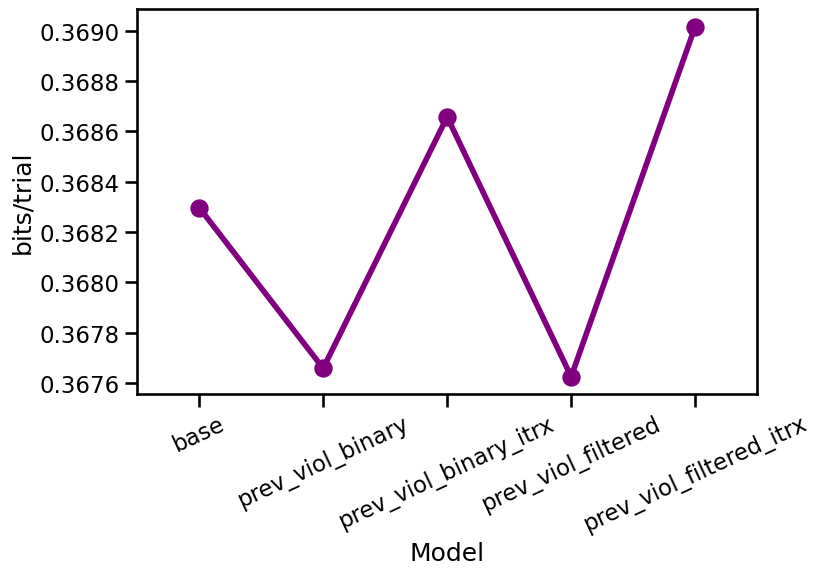

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
mvc.plot_model_comparison(
    ax=ax,
    order=ORDER,
    color="purple",
    errorbar=None,
)
ax.legend().remove()

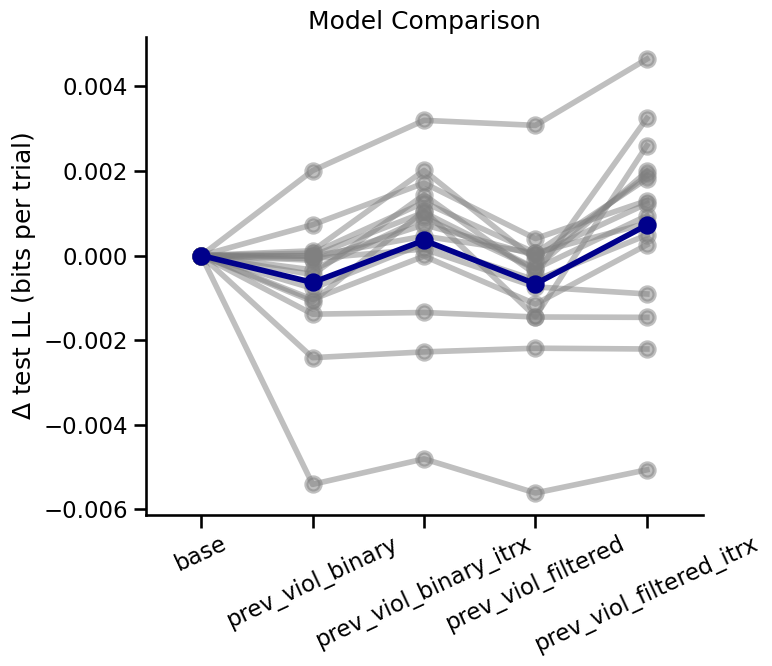

In [32]:
fig, ax = plt.subplots(figsize=(8, 7))
sns.despine()
mvc.plot_model_comparison(
    hue="animal_id",
    ax=ax,
    order=ORDER,
    palette=["gray"] * 16,
    alpha = 0.5,
    y="bits_per_trial_relative_to_base"
)
mvc.plot_model_comparison(
    ax=ax,
    order=ORDER,
    color=c.MODEL_COMPARE_COLOR,
    errorbar=None,
    y="bits_per_trial_relative_to_base",
    ylabel="$\Delta$ test LL (bits per trial)",
)
# ax.set_xticks(range(len(LABELS)))
# ax.set_xticklabels(LABELS, rotation=0)
ax.legend().remove()
ax.set(xlabel="", title="Model Comparison")

# save fig
plt.tight_layout()

In [33]:
bpt = mvc.compute_bits_per_trial_df()

bpt.groupby("model_name").bits_per_trial_relative_to_base.agg(["mean", "std"])

,mean,std
model_name,,
base,0.000000,0.000000
null,-1.368120,0.086600
prev_viol_binary,-0.000639,0.001599
prev_viol_binary_itrx,0.000360,0.001875
prev_viol_filtered,-0.000672,0.001744
prev_viol_filtered_itrx,0.000719,0.002309
